# Dataset & LIbraries

In [ ]:
#import kagglehub
#geadalfa_cracked_non_cracked_surface_datasets_path = kagglehub.dataset_download('geadalfa/cracked-non-cracked-surface-datasets')

#print(geadalfa_cracked_non_cracked_surface_datasets_path)

Using Colab cache for faster access to the 'cracked-non-cracked-surface-datasets' dataset.
/kaggle/input/cracked-non-cracked-surface-datasets


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras import Sequential, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils import class_weight

from PIL import Image

In [ ]:
#source_dir = geadalfa_cracked_non_cracked_surface_datasets_path + "/Bangunan Retak"
#dest_dir = "/content/drive/MyDrive/NeuralProject_Dataset"

In [ ]:
#pip install split-folders

Splitting into separate Train, Val & Test folders

In [ ]:
#import splitfolders
#splitfolders.ratio(source_dir, output=dest_dir, ratio=(.9, .05, .05), group_prefix=None, move=False)

Copying files: 96092 files [39:55, 40.11 files/s]


In [ ]:
#!zip -r -q /content/drive/MyDrive/Neural_Project/Dataset.zip /content/drive/MyDrive/NeuralProject_Dataset

!cp /content/drive/MyDrive/Neural_Project/Dataset.zip /content/

!unzip -q /content/dataset.zip -d /content/data

unzip:  cannot find or open /content/dataset.zip, /content/dataset.zip.zip or /content/dataset.zip.ZIP.


# EDA

Image size

In [ ]:
img = Image.open(dest_dir + '/train/Cracked/00001.jpg')
print(img.size)
print(img.mode)

(227, 227)
RGB


Chacking Aspect Ratio and Resolution Consistency

In [ ]:
import glob

# Get a sample of 100 images from the Cracked folder
image_paths = glob.glob(os.path.join(dest_dir, 'train', 'Cracked', '*.*'))[:100]

aspect_ratios = set()
for path in image_paths:
    with Image.open(path) as img:
        width, height = img.size
        # Calculate aspect ratio (Width / Height) rounded to 2 decimal places
        ratio = round(width / height, 2)
        aspect_ratios.add(ratio)

print(f"Unique Aspect Ratios found in sample: {aspect_ratios}")
if len(aspect_ratios) == 1 and 1.0 in aspect_ratios:
    print("Description: Data is consistently perfectly square (1:1).")
else:
    print("Description: Data contains mixed aspect ratios. Distortion may occur during resizing.")

Unique Aspect Ratios found in sample: {1.0}
Description: Data is consistently perfectly square (1:1).


Since the aspect rations are the same, it's safe to squish all the images to 224x224. The reason for that will be discussed in the Bonus part.

Data Loading & Preprocessing

In [ ]:
gen = ImageDataGenerator(rescale=1./255)

train = gen.flow_from_directory(dest_dir + '/train', target_size=(224, 224), batch_size=32, class_mode='categorical', color_mode='rgb')
val = gen.flow_from_directory(dest_dir + '/val', target_size=(224, 224), batch_size=32, class_mode='categorical', color_mode='rgb')
test = gen.flow_from_directory(dest_dir + '/test', target_size=(224, 224), batch_size=32, class_mode='categorical', color_mode='rgb')

NameError: name 'ImageDataGenerator' is not defined

In [ ]:
from PIL import Image
import numpy as np

sizes = []
channels = []

sample_imgs = test[:100]

for img_path in sample_imgs:
    img = Image.open(img_path)
    sizes.append(img.size)
    channels.append(len(img.getbands()))

print("Unique image sizes:", set(sizes))
print("Channels:", set(channels))



We will apply data augmentation later for the CNN,  because
 for the FFNN it will do more harm than good!

## Visualization

### Class Distribution Plot

/tmp/ipykernel_33934/686178491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train.classes , palette='viridis')


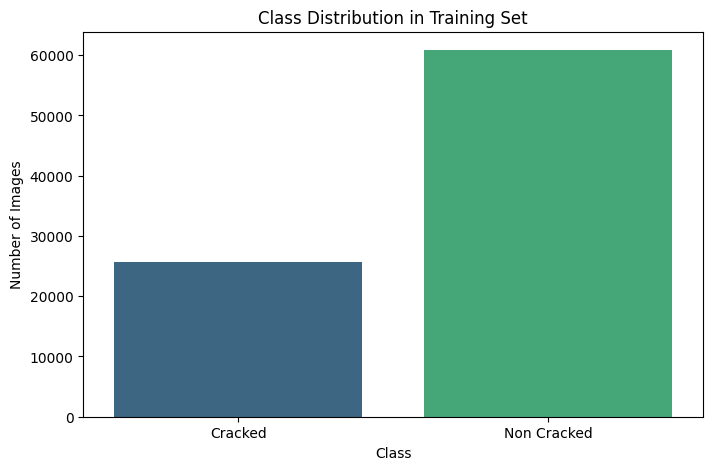

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=train.classes , palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Images')

plt.xticks(ticks=[0, 1], labels=['Cracked', 'Non Cracked'])
plt.show()

### Sample Image Visualization

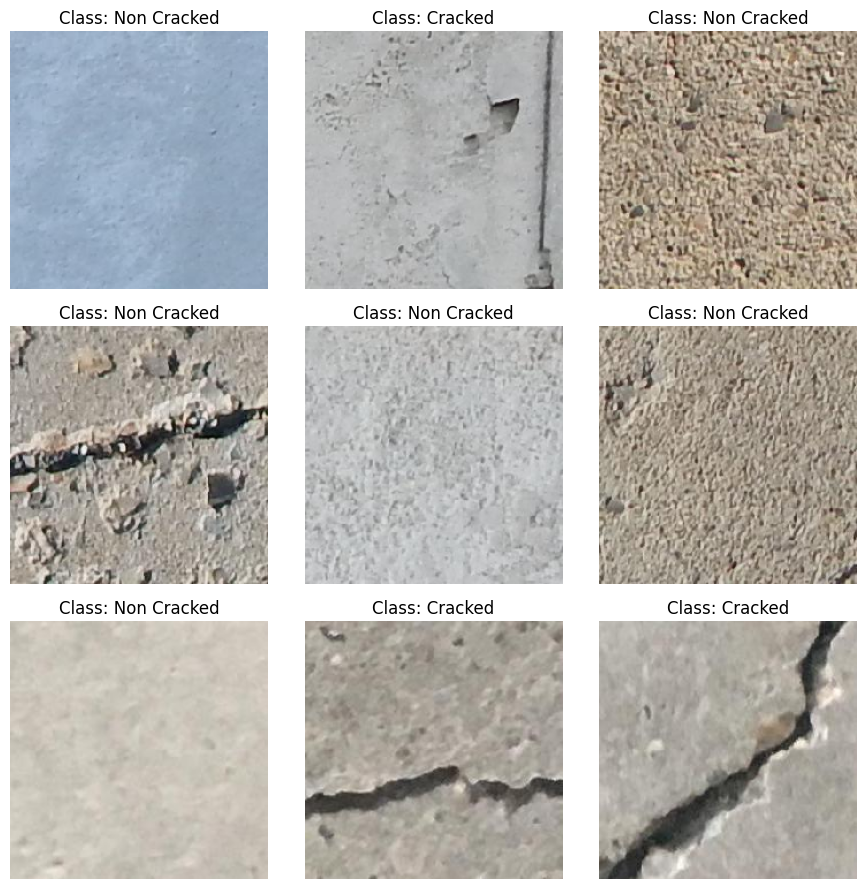

In [ ]:
# Fetch a batch of images and labels
images, labels = next(train)

# Create a reverse dictionary to map integer indices back to string labels
label_map = {v: k for k, v in train.class_indices.items()}

plt.figure(figsize=(9, 9))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_idx = np.argmax(labels[i])
    class_name = label_map[class_idx]
    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Pixel Intensity Distribution

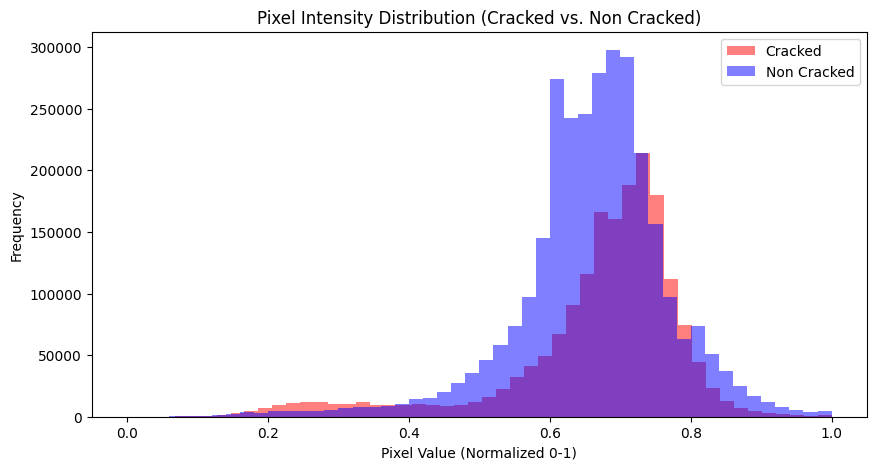

In [ ]:
# Fetch a batch of images and labels
images, labels = next(train)

# Separate the images based on their labels
cracked_images = images[np.argmax(labels, axis=1) == 0]
non_cracked_images = images[np.argmax(labels, axis=1) == 1]

plt.figure(figsize=(10, 5))
# Flatten the image arrays and plot their histograms
plt.hist(cracked_images.ravel(), bins=50, color='red', alpha=0.5, label='Cracked')
plt.hist(non_cracked_images.ravel(), bins=50, color='blue', alpha=0.5, label='Non Cracked')

plt.title('Pixel Intensity Distribution (Cracked vs. Non Cracked)')
plt.xlabel('Pixel Value (Normalized 0-1)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Average Image per Class

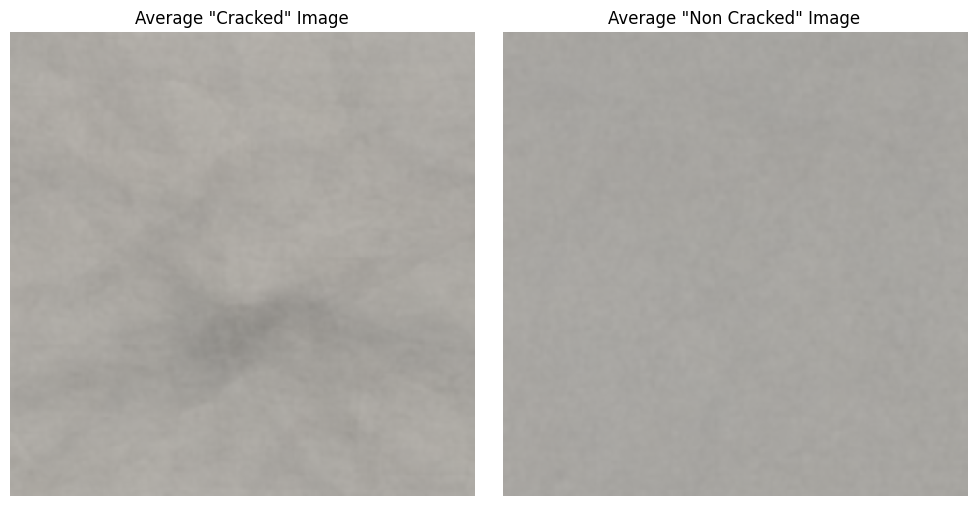

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fetch a few batches to get a decent sample size
num_batches = 5
all_cracked = []
all_non_cracked = []

for _ in range(num_batches):
    images, labels = next(train)
    # Filter based on the labels (assuming 0=Cracked, 1=Non Cracked)
    cracked = images[np.argmax(labels, axis=1) == 0]
    non_cracked = images[np.argmax(labels, axis=1) == 1]

    if len(cracked) > 0: all_cracked.append(cracked)
    if len(non_cracked) > 0: all_non_cracked.append(non_cracked)

# Concatenate and calculate the mean across the sample
mean_cracked = np.mean(np.vstack(all_cracked), axis=0)
mean_non_cracked = np.mean(np.vstack(all_non_cracked), axis=0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(mean_cracked)
plt.title('Average "Cracked" Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mean_non_cracked)
plt.title('Average "Non Cracked" Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### Edge Detection Simulation

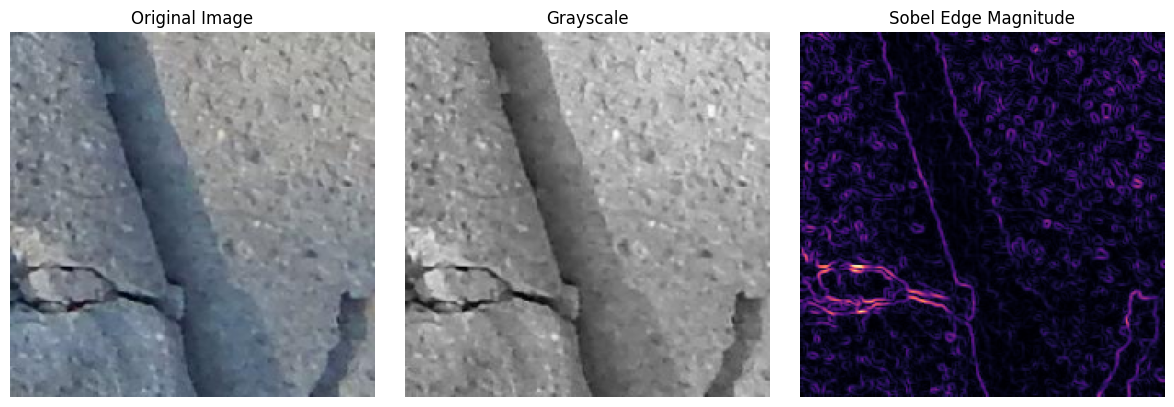

In [ ]:
import tensorflow as tf

# Fetch one batch and select the first 'Cracked' image
images, labels = next(train)
cracked_idx = np.where(np.argmax(labels, axis=1) == 0)[0][0]
sample_img = images[cracked_idx]

# Convert the image to grayscale and add a batch dimension for the tf.image function
gray_img = tf.image.rgb_to_grayscale(sample_img)
gray_img_expanded = tf.expand_dims(gray_img, 0)

# Apply Sobel edge detection (returns edges along Y and X axes)
edges = tf.image.sobel_edges(gray_img_expanded)

# Extract the vertical (X) and horizontal (Y) edges
edges_y = edges[0, :, :, 0, 0]
edges_x = edges[0, :, :, 0, 1]

# Calculate the combined edge magnitude
edge_magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_img[:, :, 0], cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edge_magnitude, cmap='magma')
plt.title('Sobel Edge Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()